In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
from torch.utils.data import random_split
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
import seaborn as sns 

In [3]:
MODEL_NAME = "clf_3"
BATCH_SIZE = 128
LEARNING_RATE = 0.001
NUM_EPOCHS = 20

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [5]:
transform = transforms.ToTensor()

full_train = datasets.FashionMNIST(root="./data", train=True, download=True, transform=transform)

train_size = int(0.9 * len(full_train))
val_size = len(full_train) - train_size

train_data, val_data = random_split(full_train, [train_size, val_size])

train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_data, batch_size=BATCH_SIZE, shuffle=False)

test_data = datasets.FashionMNIST(root="./data", train=False, download=True, transform=transform)
test_loader = DataLoader(test_data, batch_size=BATCH_SIZE, shuffle=False)

In [6]:
dataiter = iter(train_loader)
images, labels = next(dataiter)
print(torch.min(images), torch.max(images))

tensor(0.) tensor(1.)


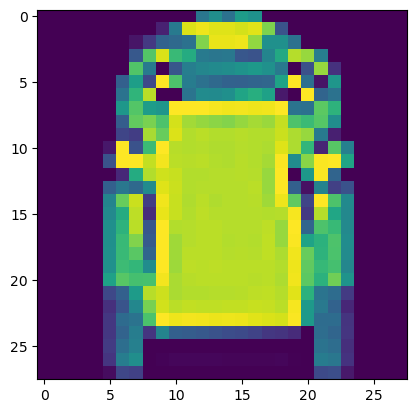

In [7]:
image = images[0]
image = image.permute(1, 2, 0)
plt.imshow(image)

In [8]:
class MNIST_CNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=4, stride=2, padding=1), # 32 x 14 x 14
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1), # 64 x 7 x 7
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1), # 128 x 3 x 3
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Flatten(),
            nn.Linear(128*3*3, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        return self.net(x)

In [10]:
loaded_checkpoint = torch.load(r"C:\Users\ea197\Projects\Literature-Review-ML\CNN_clf_FASHION\clf_3_best.pth", map_location=device)

model = MNIST_CNN().to(device)

model.load_state_dict(loaded_checkpoint["model_state"])

C:\Users\ea197\AppData\Local\Temp\ipykernel_16200\1339471764.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  loaded_checkpoint = torch.load(r"C:\Users\ea197\Projects\Lit

<All keys matched successfully>

In [11]:
print(loaded_checkpoint["epoch"])

17


In [12]:
all_preds = []
all_labels = []

model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        logits = model(images)
        preds = logits.argmax(dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

In [13]:
test_accuracy = accuracy_score(all_labels, all_preds)
print(f"Test Accuracy: {test_accuracy*100:.2f}%")

Test Accuracy: 91.43%


In [14]:
cm = confusion_matrix(all_labels, all_preds)

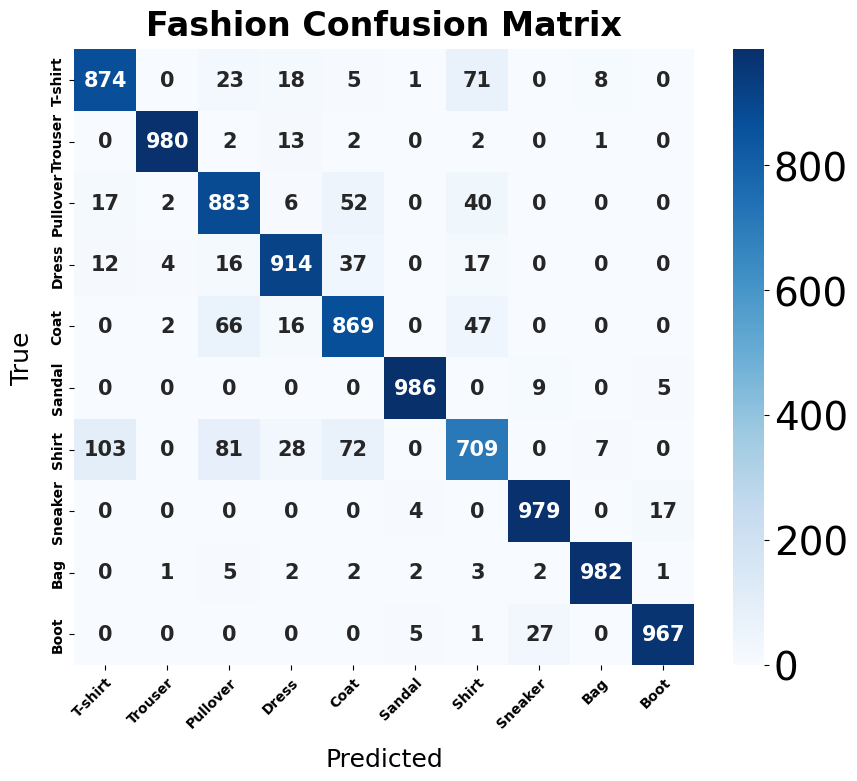

In [15]:
plt.figure(figsize=(10, 8))

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", annot_kws={"size": 15, "weight": "bold"},
            xticklabels=[
                "T-shirt", "Trouser", "Pullover", "Dress", "Coat",
                "Sandal", "Shirt", "Sneaker", "Bag", "Boot"
            ],
            yticklabels=[
                "T-shirt", "Trouser", "Pullover", "Dress", "Coat",
                "Sandal", "Shirt", "Sneaker", "Bag", "Boot"
            ])

plt.tick_params(axis='x', labelsize=10)
plt.tick_params(axis='y', labelsize=10)

ax = plt.gca()
for tick in ax.get_xticklabels():
    tick.set_fontweight("bold")
for tick in ax.get_yticklabels():
    tick.set_fontweight("bold")

plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

plt.xlabel("Predicted", fontsize=18, labelpad=12)
plt.ylabel("True", fontsize=18, labelpad=12)

plt.title("Fashion Confusion Matrix", fontsize=24, pad=10, fontweight="bold")

cbar = plt.gca().collections[0].colorbar
cbar.ax.tick_params(labelsize=28)

plt.savefig("fashion_confusion_matrix.pdf", bbox_inches="tight")
plt.show()

In [16]:
class_names = [
    "T-shirt", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Boot"
]

print(classification_report(all_labels, all_preds, target_names=class_names))

              precision    recall  f1-score   support

     T-shirt       0.87      0.87      0.87      1000
     Trouser       0.99      0.98      0.99      1000
    Pullover       0.82      0.88      0.85      1000
       Dress       0.92      0.91      0.92      1000
        Coat       0.84      0.87      0.85      1000
      Sandal       0.99      0.99      0.99      1000
       Shirt       0.80      0.71      0.75      1000
     Sneaker       0.96      0.98      0.97      1000
         Bag       0.98      0.98      0.98      1000
        Boot       0.98      0.97      0.97      1000

    accuracy                           0.91     10000
   macro avg       0.91      0.91      0.91     10000
weighted avg       0.91      0.91      0.91     10000

